# FAANG Stock Analysis — Winter 25/26 Assessment

## Introduction
This notebook outlines the requirements for the Winter 25/26 assessment in the Computer Infrastructure module.
It specifies four core tasks: **data collection, data visualisation, scripting, and automation.**
Completion of these tasks will demonstrate proficiency in Python programming, reproducible analysis, and continuous integration and continuous deployment (CI/CD) workflows, using FAANG stock data as a case study.

## Assessment Tasks
- Retrieve hourly open, high, low, close, and volume (OHLCV) data for FAANG tickers and save the results as timestamped CSV files in the data directory.
- Generate plots of closing prices for each of the five stocks and save the images as PNG files in the plots directory.
- Convert the notebook logic into a command-line interface (CLI) script.
- Automate the execution of the workflow using GitHub Actions. 

### 📦 Import Libraries
This section imports the Python libraries needed for data manipulation, financial data retrieval, and plotting.

- `pathlib.Path` → Cross‑platform file and folder handling  
- `datetime` → Timestamped filenames for reproducibility  
- `pandas` → Data manipulation and analysis  
- `yfinance` → Financial data API for stock history  
- `matplotlib.pyplot` → Static plotting  
- `seaborn` → Enhanced plotting styles
- `numpy` → Numerical operations

In [1]:
%matplotlib inline

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

---

## Helper Functions

Reusable functions promote modularity, reproducibility, and clarity in both the notebook and command-line interface (CLI) script.

- **verify_environment():** Checks connectivity to the yfinance API by retrieving sample data for Apple (AAPL) and employs exception handling to report errors.
- **fetch_hourly_history():** Retrieves five days of hourly OHLCV data for a specified ticker, formatting the output with a datetime index and ticker label.
- **save_hourly_data():** Aggregates data from multiple tickers and saves it to a timestamped CSV file in the data directory. Overwriting is prevented unless explicitly permitted.
- **load_latest_data():** Loads the most recent CSV file and separates the data into individual DataFrames for each ticker, with optional previews available for inspection.

Relevant to **Problem 1 (Data Collection) and Problem 2 (Visualisation).**

### References:
-  [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)
-  [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)
-  [yfinance Quickstart](https://pypi.org/project/yfinance/)

In [2]:
# helper function to display dataframes in Jupyter notebooks
# this function checks yfinance connectivity by fetching sample data and optionally displaying it, 
# ensuring the environment is ready for data operations. 
# 📖 [Reference: yfinance Quickstart](https://pypi.org/project/yfinance/)
def verify_environment(show_preview=True):
    """Check yfinance connectivity and preview sample data."""
    try:
        df = yf.Ticker("AAPL").history(period="1d", interval="1h")
        print(f"✅ yfinance test passed — rows: {df.shape[0]}")
        if show_preview:
            display(df.head())
        return True
    except Exception as e:
        print(f"❌ yfinance test failed: {e}")
        return False

# helper function to fetch hourly data for a ticker
# this function retrieves 5 days of hourly OHLCV data for a given ticker and formats it for downstream analysis. 
# 📖 [Reference: yfinance.Ticker.history](https://github.com/ranaroussi/yfinance)
def fetch_hourly_history(ticker):
    """Fetch hourly OHLCV data for a single ticker."""
    try:
        df = yf.Ticker(ticker).history(period='5d', interval='1h')
        if df.empty:
            print(f"⚠️ No data for {ticker}")
            return None
        df['Ticker'] = ticker
        df.index.name = 'Date'
        return df
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        return None

# ticker for FAANG stocks
# this function aggregates hourly data for multiple tickers and saves it to a timestamped CSV, 
# supporting reproducibility and version control. 
# 📖 [Reference: pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)
def save_hourly_data(tickers, output_dir, overwrite=False):
    """Save combined hourly data for all tickers to a timestamped CSV."""
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Saving to directory: {output_dir}")

    # Fetch data for each ticker
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            print(f"✅ {t}: {len(df)} rows")
            dfs.append(df)
        else:
            print(f"⚠️ {t}: No valid data")

    # Exit if no valid data
    if not dfs:
        print("🚫 No valid data to save.")
        return None

    # Combine and save
    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"

    # Check for overwrite condition
    if path.exists():
        if overwrite:
            print(f"⚠️ Overwriting existing file: {path.name}")
        else:
            print(f"🛑 File already exists and overwrite=False: {path.name}")
            return None

    try:
        final_df.to_csv(path, index_label='Date')
        print(f"✅ Data saved to {path}")
        return str(path)
    except Exception as e:
        print(f"❌ Failed to save file: {e}")
        return None


# helper function to load the latest data file
# this function loads the most recent CSV file and splits it into individual DataFrames per ticker 
# for targeted plotting or analysis. 
# 📖 [Reference: pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)
def load_latest_data(tickers, folder='data', show_preview=True):
    """Load the most recent CSV and split into ticker-specific DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        raise FileNotFoundError("No CSV files found.")
    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    if show_preview:
        for t, subdf in data.items():
            print(f"{t}: {subdf.shape}")
            display(subdf.head())
    return data


---

## Setup and Configuration

This section initialises the environment required for data analysis and visualisation.

- **The following plotting libraries are imported:**
  - matplotlib.pyplot: Used for generating static plots.
  - seaborn: Provides enhanced aesthetics and a grid-based style.
- **Global flags are defined as follows:**
  - SHOW_PREVIEW: Controls the display of previews.
  - OVERWRITE: Prevents files from being overwritten unless explicitly permitted.
- **Output directories are established as follows:**
  - DATA_DIR: Specifies the location for downloaded CSV files.
  - PLOTS_DIR: Specifies the location for generated plots.
- **A consistent plotting style is applied:**
  - Default figure size is set to enhance readability.
  - A white grid background is used to improve clarity.

These configurations ensure that all subsequent steps produce clear, reproducible plots and store results in an organized structure.

### References:
- [matplotlib.pyplot documentation](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot)
- [Seaborn aesthetics tutorial](https://seaborn.pydata.org/tutorial/aesthetics.html)


In [3]:
# 🖼️ Plotting Configuration
# The following settings configure the visual style for plots.
# Note: matplotlib.pyplot and seaborn were imported in a previous cell.
# - matplotlib.pyplot is used for creating static line plots.
# - seaborn enhances plot aesthetics and applies a clean grid-based style.

# Global flags
SHOW_PREVIEW = True
OVERWRITE = False

# Output directories
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()

# Plotting style
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')


---

## Step 1: Environment Check

This step confirms that the environment is correctly configured to retrieve financial data using the yfinance API.
This verification is a critical prerequisite for Problem 1 (Data Collection), since subsequent tasks depend on reliable access to hourly stock data.

### Objectives:

* **Retrieves hourly data for Apple (AAPL)** to confirm the functionality of the API connection.
* **Displays a dataset preview** when SHOW_PREVIEW is enabled, facilitating visual inspection of the structure and verification of expected columns, including Open, High, Low, Close, and Volume.
* **Handles errors** using Python’s try-except block to ensure that issues, such as connectivity problems, are reported clearly and do not interrupt the workflow.

Conducting this check initially ensures that the system is prepared for reproducible data collection and analysis.
This approach is consistent with best practices in infrastructure automation and establishes a foundation for subsequent assessment tasks.

Relevant to **Problem 1 (Data Collection).**

### References:  
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)  
- [yfinance Quickstart](https://pypi.org/project/yfinance/)  


In [4]:
# Run environment verification
verify_environment(SHOW_PREVIEW)


✅ yfinance test passed — rows: 2


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-12-10 09:30:00-05:00,277.869995,278.792999,276.584991,277.450012,3868165,0.0,0.0
2025-12-10 10:30:00-05:00,277.454987,277.540009,276.440002,276.630005,1060307,0.0,0.0


True

---

## Step 2: Problem 1 – Fetching and Saving FAANG Data

This section outlines the data collection phase of the workflow. The wrapper function get_data() calls the helper function save_hourly_data() to retrieve and store reproducible FAANG stock datasets.

### Overview of Helper Functionality:
  The save_hourly_data() function executes the following primary tasks:
  - Establishes a connection to the yfinance API.
  - Retrieves hourly OHLCV (Open, High, Low, Close, Volume) stock data for the preceding five days.
  - Creates the data/ directory if it does not already exist.
  - Saves each ticker's dataset into a uniquely timestamped .csv file.

### List of FAANG Tickers:
  - Facebook: META
  - Apple: AAPL
  - Amazon: AMZN
  - Netflix: NFLX
  - Google: GOOG
- **The collected data includes hourly OHLCV prices, where each Close value corresponds to the hourly closing price for each ticker.**
- **Datasets are stored as .csv files in the data/ directory, each assigned a unique timestamp in the format YYYYMMDD-HHmmss.csv.**
- **The helper function automates both directory creation and file naming.**

This modular design ensures the availability of up-to-date, reproducible datasets for subsequent tasks such as plotting and analysis. Separating the responsibilities of get_data() and save_hourly_data() improves clarity, maintainability, and alignment with best practices in reproducible workflows.

This process is directly relevant to **Problem 1 (Data Collection).**

### References:  
- [yfinance Documentation](https://pypi.org/project/yfinance/)  
- [pandas.DataFrame.to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html)  
- [Real Python Modules](https://realpython.com/python-modules-packages/)  


In [5]:
def get_data():
    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
    output_dir = Path("data")
    save_hourly_data(tickers, output_dir)   # uses helper
    print("✅ Data fetched and saved.")

# Call the function
get_data()


📁 Saving to directory: data
✅ META: 30 rows
✅ AAPL: 30 rows
✅ AMZN: 30 rows
✅ NFLX: 30 rows
✅ GOOG: 30 rows
✅ Data saved to data\20251210-160302.csv
✅ Data fetched and saved.


---

## Step 3: Load and Diagnose Data

This step begins data preparation by using the load_latest_data() helper function to retrieve the latest CSV file from the data/ folder, split the data into separate DataFrames for each FAANG ticker, and confirm dataset validity for analysis.

- **Helper Functionality Overview:**
  The load_latest_data() function performs the following core tasks:
  - Loads the most recent dataset generated in Step 2.
  - Splits the data by ticker, storing each FAANG company’s records in a dedicated DataFrame within a dictionary called data.
  - Checks each DataFrame for the correct ticker and ensures data rows are present.

- **List of FAANG Tickers:**
  - Facebook: META
  - Apple: AAPL
  - Amazon: AMZN
  - Netflix: NFLX
  - Google: GOOG

- The "Close" column in each DataFrame contains the hourly closing price for each ticker, recorded at the end of each trading interval.
- Weekend and Holiday Data: yfinance provides hourly data only through the most recent trading day.
  - On weekdays, the dataset includes hourly intraday closing prices.
  - On weekends or holidays, the dataset ends with the final closing price from the last trading session.

Diagnosing the dataset at this stage ensures the data from Step 2 is valid and ready for visualisation in Step 4.

Relevant to **Problem 2 (Visualisation)**

### References:  
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python File Handling](https://docs.python.org/3/library/pathlib.html)  
- [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)  


In [6]:
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
DATA_DIR = Path("data")
SHOW_PREVIEW = True

# Use helper to load the latest dataset and split by ticker
data = load_latest_data(tickers, folder=str(DATA_DIR), show_preview=SHOW_PREVIEW)

# Diagnostic check: confirm each ticker is present and has data
print("📋 Ticker load status:")
for t in tickers:
    if t not in data:
        print(f"{t}: ⚠️ Missing")
    elif data[t].empty:
        print(f"{t}: ⚠️ Empty")
    else:
        print(f"{t}: ✅ Loaded")


META: (30, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2025-12-04 09:30:00-05:00,666.424988,669.200012,660.109985,665.729980,10059794,0.0,0.0,META
1,2025-12-04 10:30:00-05:00,665.650024,667.590027,662.080017,664.849976,2532344,0.0,0.0,META
2,2025-12-04 11:30:00-05:00,664.739990,669.669983,664.460022,668.190002,1608145,0.0,0.0,META
3,2025-12-04 12:30:00-05:00,668.205017,668.340027,661.869995,664.765015,1307691,0.0,0.0,META
4,2025-12-04 13:30:00-05:00,664.710022,665.489990,662.260010,662.799927,879092,0.0,0.0,META


AAPL: (30, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
30,2025-12-04 09:30:00-05:00,284.109985,284.730011,280.269989,281.225006,6410843,0.0,0.0,AAPL
31,2025-12-04 10:30:00-05:00,281.209991,281.600006,279.809998,280.279999,2986361,0.0,0.0,AAPL
32,2025-12-04 11:30:00-05:00,280.285004,280.933502,279.937805,280.114990,2285394,0.0,0.0,AAPL
33,2025-12-04 12:30:00-05:00,280.130005,280.486694,279.640015,280.005005,1806229,0.0,0.0,AAPL
34,2025-12-04 13:30:00-05:00,279.989990,280.100006,278.589996,278.859985,2574486,0.0,0.0,AAPL


AMZN: (30, 9)


...

NFLX: (30, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
90,2025-12-04 09:30:00-05:00,102.930000,103.639999,102.260002,102.540001,9053564,0.0,0.0,NFLX
91,2025-12-04 10:30:00-05:00,102.535004,102.839996,102.070000,102.120003,5711567,0.0,0.0,NFLX
92,2025-12-04 11:30:00-05:00,102.114998,102.540001,101.769997,102.279999,4164476,0.0,0.0,NFLX
93,2025-12-04 12:30:00-05:00,102.285004,103.110001,102.209999,102.968903,3153877,0.0,0.0,NFLX
94,2025-12-04 13:30:00-05:00,102.964996,103.290001,102.809998,103.065002,2575441,0.0,0.0,NFLX


GOOG: (30, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
120,2025-12-04 09:30:00-05:00,321.010010,321.540009,315.600006,317.510010,4390383,0.0,0.0,GOOG
121,2025-12-04 10:30:00-05:00,317.440002,317.779999,315.954987,316.809998,1177250,0.0,0.0,GOOG
122,2025-12-04 11:30:00-05:00,316.769989,317.704010,316.630005,317.065002,1003034,0.0,0.0,GOOG
123,2025-12-04 12:30:00-05:00,317.077515,318.654999,316.480011,317.684998,882040,0.0,0.0,GOOG
124,2025-12-04 13:30:00-05:00,317.600006,318.149994,316.730011,317.281006,805792,0.0,0.0,GOOG


📋 Ticker load status:
META: ✅ Loaded
AAPL: ✅ Loaded
AMZN: ✅ Loaded
NFLX: ✅ Loaded
GOOG: ✅ Loaded


---

## Step 4: Preview of Close Prices

This cell previews the dataset from Step 3 to confirm correct structure and readiness for visualization. For each FAANG ticker, we conduct a brief diagnostic check:

- Rows loaded: Show how many rows of data were retrieved.
- Preview columns: Display the initial entries of the Date and Close columns for review.
- Warnings: Print a warning if a ticker is missing data or its DataFrame is empty.

The 'Close' column shows the hourly closing price for each ticker at the end of each trading interval. Previewing these values confirms that each stock’s movements are recorded individually, as required by the assignment.

This check confirms the dataset is valid and ready for plotting in Step 5.

Relevant to: Problem 2 (Visualisation) 

### References:  
- [Pandas DataFrame Preview](https://pandas.pydata.org/pandas-docs/stable/development/contributing_docstring.html)  
- [Python Control Flow](https://docs.python.org/3/tutorial/controlflow.html)  


In [7]:
# Preview Close prices for each ticker
print("🔍 Previewing Close prices for each ticker:")

for sym, df in data.items():
    # Check that 'Close' column exists and DataFrame is not empty
    if 'Close' in df.columns and not df.empty:
        print(f"\n{sym} — {len(df)} rows")
        # Show first few Date/Close entries for inspection
        display(df[['Date', 'Close']].head())
    else:
        print(f"{sym}: ⚠️ Missing or empty Close data")


🔍 Previewing Close prices for each ticker:

META — 30 rows


,Date,Close
0,2025-12-04 09:30:00-05:00,665.729980
1,2025-12-04 10:30:00-05:00,664.849976
2,2025-12-04 11:30:00-05:00,668.190002
3,2025-12-04 12:30:00-05:00,664.765015
4,2025-12-04 13:30:00-05:00,662.799927



AAPL — 30 rows


,Date,Close
30,2025-12-04 09:30:00-05:00,281.225006
31,2025-12-04 10:30:00-05:00,280.279999
32,2025-12-04 11:30:00-05:00,280.114990
33,2025-12-04 12:30:00-05:00,280.005005
34,2025-12-04 13:30:00-05:00,278.859985



AMZN — 30 rows


,Date,Close
60,2025-12-04 09:30:00-05:00,228.774994
61,2025-12-04 10:30:00-05:00,227.899994
62,2025-12-04 11:30:00-05:00,227.169998
63,2025-12-04 12:30:00-05:00,228.300003
64,2025-12-04 13:30:00-05:00,228.309998



NFLX — 30 rows


,Date,Close
90,2025-12-04 09:30:00-05:00,102.540001
91,2025-12-04 10:30:00-05:00,102.120003
92,2025-12-04 11:30:00-05:00,102.279999
93,2025-12-04 12:30:00-05:00,102.968903
94,2025-12-04 13:30:00-05:00,103.065002



GOOG — 30 rows


,Date,Close
120,2025-12-04 09:30:00-05:00,317.510010
121,2025-12-04 10:30:00-05:00,316.809998
122,2025-12-04 11:30:00-05:00,317.065002
123,2025-12-04 12:30:00-05:00,317.684998
124,2025-12-04 13:30:00-05:00,317.281006


---

### 📊 Step 5 — Summary Statistics

This cell generates a **statistical summary** of the hourly closing prices for each FAANG stock, using Pandas’ built‑in `.describe()` method. This provides context before visualisation by highlighting the distribution and variability of the data.

The summary includes:
- **Mean** → the average hourly closing price  
- **Median** → the middle hourly value  
- **Standard deviation** → the variability of hourly prices  
- **Minimum and maximum** → the lowest and highest hourly closes  

These statistics are calculated directly from the `Close` column in each ticker’s DataFrame. Reviewing them gives a snapshot of each stock’s behaviour — spotting patterns such as which stock tends to be higher priced, the range of values, and any unusual fluctuations.

This step provides useful context for interpreting plots and supports deeper analysis, even though it is not part of the formal assessment. It prepares the dataset for **Step 6 (Plotting)**, aligning with **Problem 2 (Visualisation)** in the Winter 25/26 assessment.

Relevant to: **Problem 2 (Visualisation)** and **Optional Step: Analysis**  

References:  
- [Pandas describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)  
- [Python Statistics Module](https://docs.python.org/3/library/statistics.html)  


In [8]:
# Generate summary statistics for hourly Close prices
for sym, df in data.items():
    print(f"Summary statistics for {sym}")
    # Use Pandas .describe() to compute mean, median, std, min, max, etc.
    display(df['Close'].describe())


Summary statistics for META


count     30.000000
mean     664.224042
std        6.987500
min      648.909973
25%      657.608734
50%      666.107483
75%      669.265869
max      673.638000
Name: Close, dtype: float64

Summary statistics for AAPL


count     30.000000
mean     278.509677
std        1.327394
min      276.359985
25%      277.452507
50%      278.350006
75%      279.403755
max      281.225006
Name: Close, dtype: float64

Summary statistics for AMZN


count     30.000000
mean     228.549990
std        1.198172
min      226.974197
25%      227.854996
50%      228.305000
75%      229.357498
max      231.735001
Name: Close, dtype: float64

Summary statistics for NFLX


count     30.000000
mean      98.807930
std        3.091920
min       94.858200
25%       96.076752
50%       96.904999
75%      101.742502
max      104.665001
Name: Close, dtype: float64

Summary statistics for GOOG


count     30.000000
mean     317.671337
std        2.820933
min      312.832397
25%      316.104538
50%      317.764999
75%      318.722496
max      322.464996
Name: Close, dtype: float64

### 🛠️ Step 6 — Data Quality Check

This cell performs a **data quality check** to confirm that the dataset is reliable before plotting or calculating returns. For each FAANG ticker’s DataFrame, we validate data integrity by checking:

- **Missing values (NaNs):** Gaps in the dataset that could cause errors in calculations or plots.  
- **Empty datasets:** Cases where no rows of data were loaded for a ticker.  

The `Close` column in each DataFrame represents the **hourly closing price per ticker**, captured at each trading interval close. By validating these hourly values, we ensure that each stock’s dataset is complete and ready for analysis.

Catching issues at this stage makes the workflow more robust and prevents problems later in visualisation or analysis. This proactive check aligns with best practices in reproducible data collection and supports the integrity of the Winter 25/26 assessment tasks.

Relevant to: **Problem 1 (Data Collection)** and **Optional Steps: Analysis**  

References:  
- [Pandas isnull()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)  
- [Pandas Missing Data Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html)  


In [9]:
# Data quality check for each ticker's DataFrame in the 'data' dictionary
for sym, df in data.items():
    # Check for missing values
    if df.isnull().values.any():
        print(f"{sym}: ⚠️ Missing values detected")
        # Show count of missing values per column
        display(df.isnull().sum())
    # Check for empty DataFrame
    elif df.empty:
        print(f"{sym}: ⚠️ DataFrame is empty")
    # Confirm dataset is clean
    else:
        print(f"{sym}: ✅ No missing values")


META: ✅ No missing values
AAPL: ✅ No missing values
AMZN: ✅ No missing values
NFLX: ✅ No missing values
GOOG: ✅ No missing values


### 🔄 Step 6a — Extend DataFrames with Returns & Rolling Mean

This cell extends each FAANG ticker’s DataFrame by adding two derived metrics that make the dataset more useful for analysis. Using Pandas’ built‑in `.pct_change()` and `.rolling().mean()` methods, we enrich the raw hourly closing prices with:

- **Return** → the hour‑to‑hour percentage change in the `Close` column.  
  - Provides a measure of volatility by showing how much the stock moves between consecutive closes.  

- **RollingMean** → a smoothed average of the `Close` column over the last 30 periods.  
  - Highlights longer‑term trends by reducing the “noise” of short‑term hourly fluctuations.  

Both metrics are applied **per ticker individually**, ensuring that each stock’s behaviour is captured separately and consistently with the assignment requirements.

By extending the dataset with these derived values, we prepare it for deeper visualisations such as histograms, boxplots, and moving averages, as well as more meaningful comparisons across tickers. This mirrors common approaches in tutorials (e.g., GeeksforGeeks), which often use daily intervals, but here we adapt the method to the required hourly data.

Relevant to: **Optional Steps: Analysis** — This step is not part of the formal assessment but provides extra insight for exploration.  

References:  
- [Pandas pct_change()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)  
- [Pandas rolling()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)  


In [10]:
# Extend each ticker's DataFrame with derived metrics
for sym, df in data.items():
    # Hour-to-hour percentage change in Close prices
    df['Return'] = df['Close'].pct_change()
    # 30-period rolling mean of Close prices
    df['RollingMean'] = df['Close'].rolling(window=30).mean()


### 📈 Step 7 — Plot Close Prices  

This cell defines the `plot_data()` function, our **visualisation tool** for plotting FAANG hourly closing prices. Using Matplotlib and Pandas, it produces a single line chart showing how the stocks move over time.

What this step does:
- **Opens the latest CSV file** in the `data/` folder.  
- **Plots the hourly `Close` prices** for all FAANG tickers together on one chart.  
- **Adds axis labels, a legend, and a title** that shows the last available trading date from the dataset.  
- **Saves the plot** into the `plots/` folder with a timestamped filename (`YYYYMMDD-HHmmss.png`) so each run is stored separately.  
- **Displays the plot inline** in the notebook for immediate review.  

The plot shows the **hourly closing prices per ticker**, captured at each trading interval close.  
- On weekdays when markets are open, hourly closes are plotted up to the current time.  
- On weekends or holidays, no new hourly data is available, so the latest file stops at the final close of the last trading session.  
- To make this clear, the chart title is updated to show *“FAANG Hourly Closing Prices — up to YYYY‑MM‑DD”*, where the date corresponds to the last available data point in the CSV.  

This step is important because it fulfils the assessment requirement by generating the required plot and ensures that the meaning of the `Close` values is clear. Later optional steps will build on this by adding deeper analysis and interpretation.

Relevant to: **Problem 2 (Visualisation)**  

References:  
- [Matplotlib Pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot)  
- [Pandas Plotting](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)  


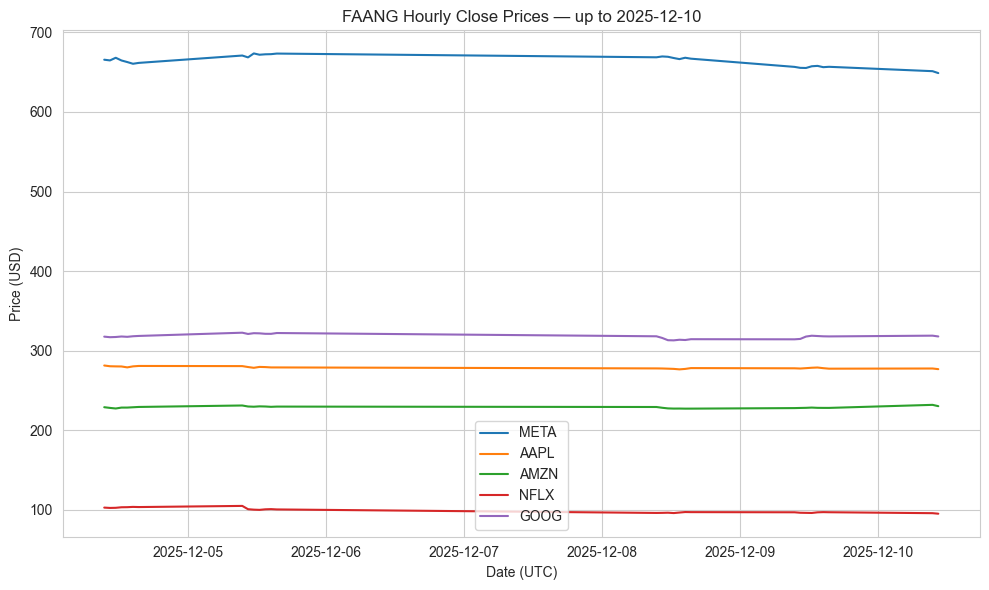

✅ Plot saved: plots\20251210-160302.png


In [11]:
def plot_data():
    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
    # Load the latest dataset without preview
    data = load_latest_data(tickers, folder="data", show_preview=False)

    # Ensure plots directory exists
    PLOTS_DIR = Path("plots")
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    last_dates = []

    # Plot Close prices for each ticker
    for sym, df in data.items():
        if 'Date' in df.columns and 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = pd.to_numeric(df['Close'], errors='coerce')
            ax.plot(x, y, label=sym)
            last_dates.append(x.max())

    # Determine last available trading date for title
    title_date = "No data"
    if last_dates and pd.notnull(max(last_dates)):
        title_date = pd.to_datetime(max(last_dates)).strftime('%Y-%m-%d')

    # Add labels, legend, and title
    ax.set_title(f"FAANG Hourly Close Prices — up to {title_date}")
    ax.set_xlabel("Date (UTC)")
    ax.set_ylabel("Price (USD)")
    ax.legend()

    # Save plot with timestamped filename
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    filename = PLOTS_DIR / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(str(filename))

    # Display plot inline
    plt.show()
    print(f"✅ Plot saved: {filename}")

# Call the function
plot_data()


### 📌 Requirements Compliance Checklist

This section confirms that the notebook meets the assessment requirements for **Problem 1 (Data Collection)** and **Problem 2 (Visualisation)**.

**Problem 1: Data from yfinance**
- ✔ Function `get_data()` defined  
- ✔ Downloads **hourly OHLCV data** for the last 5 days  
- ✔ Covers FAANG tickers: META, AAPL, AMZN, NFLX, GOOG  
- ✔ Saves data into `data/` folder  
- ✔ Filenames follow format `YYYYMMDD-HHmmss.csv`  
- ✔ Creates `data/` folder automatically if missing  

**Problem 2: Plotting Data**
- ✔ Function `plot_data()` defined  
- ✔ Opens latest CSV file in `data/`  
- ✔ Plots hourly `Close` prices for all FAANG tickers on one chart  
- ✔ Adds axis labels, legend, and title with last available trading date  
- ✔ Saves plot into `plots/` folder with timestamped filename `YYYYMMDD-HHmmss.png`  
- ✔ Creates `plots/` folder automatically if missing  
- ✔ Displays plot inline in the notebook  

**Clarification:**  
All plotted values are **hourly closes**, not daily closes. Each point reflects the end of a one‑hour trading interval, exactly as required by the assignment.


## Step 8 — Optional Analysis Plots (Introductory Description)

This section introduces **optional, exploratory plots** that build on the Step 1 data dictionary and the derived `Return` and `RollingMean` columns from Step 6a. Each plot has its own short explanation cell and code cell.

### 📊 Upcoming Plots & Benefits

- **Step 8a — Histogram + KDE of Returns**  
  *Reveals the distribution shape, tails, and outliers for each ticker; useful for spotting non‑normality and extreme intraday moves.*

- **Step 8b — Pairwise Scatterplot Matrix (Pairplot)**  
  *Visualises pairwise relationships and joint distributions between tickers’ synchronous returns; highlights non‑linear relationships and niche clusters.*

- **Step 8c — Correlation Analysis (Hourly Returns)**  
  *Summarises linear co‑movement across tickers using Pearson correlation; compact view for diversification and risk discussion.*

- **Step 8d — Cumulative Returns vs Equal‑weight FAANG**  
  *Compares compounded performance of each ticker to a simple equal‑weight FAANG benchmark; shows relative outperformance and path differences.*

- **Step 8e — Rolling Average Plots**  
  *Overlays 30‑period moving averages on hourly closes; smooths short‑term noise to reveal longer‑term trends.*

### 📝 Usage Notes
- All plots read `Close` (and `Date`) from Step 1 frames.  
- Returns are computed from prices when missing.  
- Plots are **exploratory only** and do not modify saved files.  

### 📚 References
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change)
- [pandas rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)
- [seaborn plotting](https://seaborn.pydata.org/)  


### Step 8a — Histogram + KDE of Returns

This optional, display‑only cell plots a **histogram with KDE overlay** for each ticker’s hourly returns.

**What it does**  
- Ensures a valid `Return` column (computes `pct_change` from `Close` if missing).  
- Cleans NaNs from the returns series.  
- Plots one histogram + KDE per ticker, with the dataset’s last timestamp in the title.  

**Why it’s useful**  
*Reveals skew, tails, multimodality, and outliers; helps assess volatility and whether normality assumptions are reasonable.*  

**Notes for use**  
- Adjust bins or KDE bandwidth if needed.  
- KDE can be unstable for very small samples.  
- This cell is **exploratory only** and does not save files.  

**Reviewer hint**  
- Titles include the last available data date so plots can be traced back to the input CSV.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)  
- [seaborn histplot / kdeplot](https://seaborn.pydata.org/)  


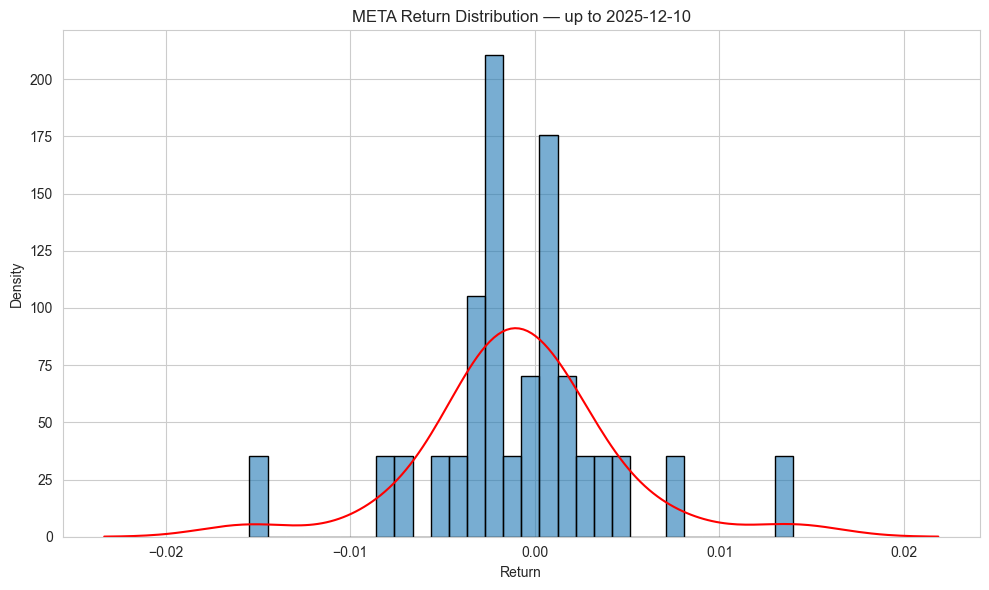

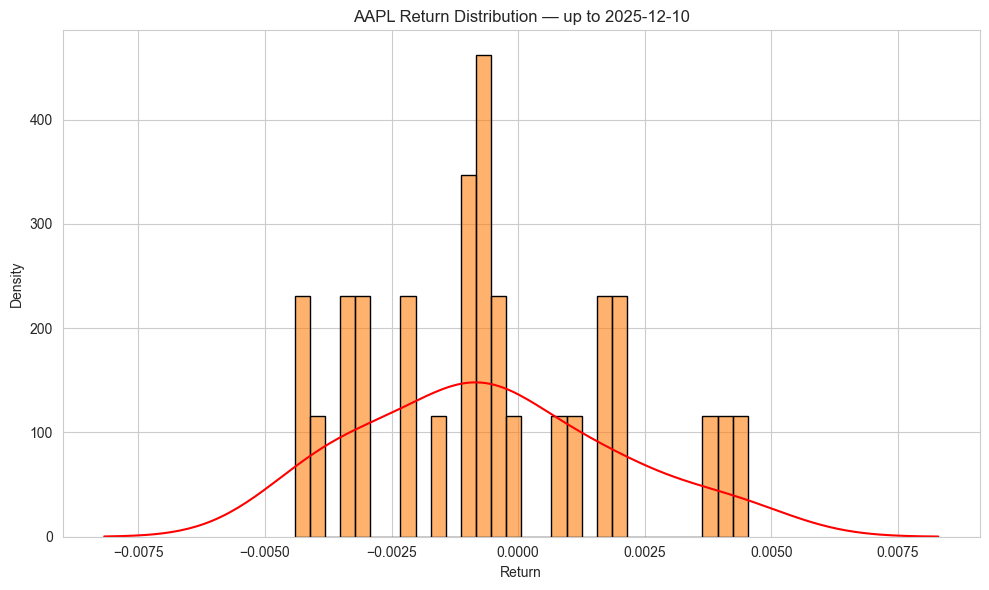

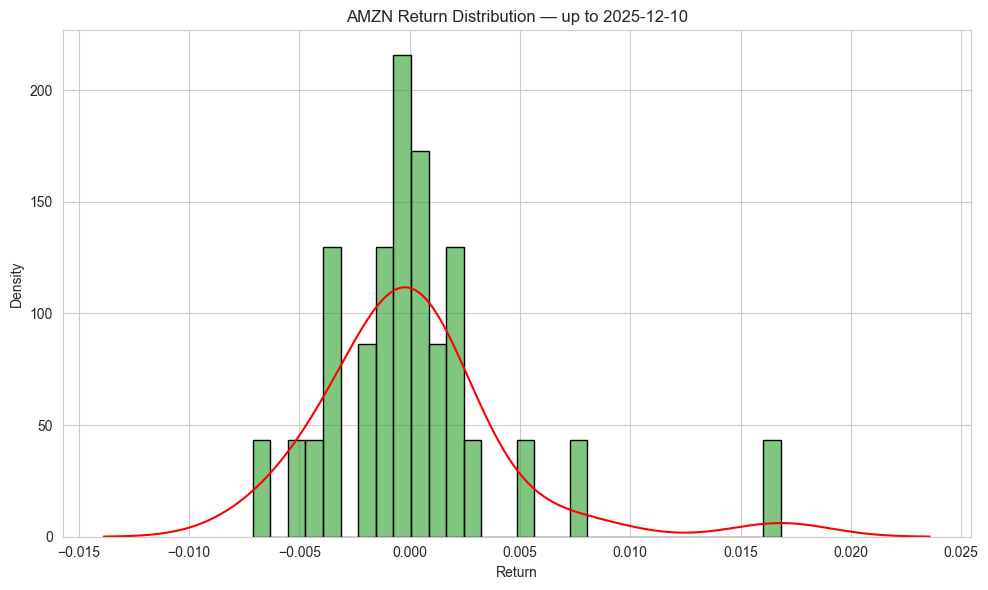

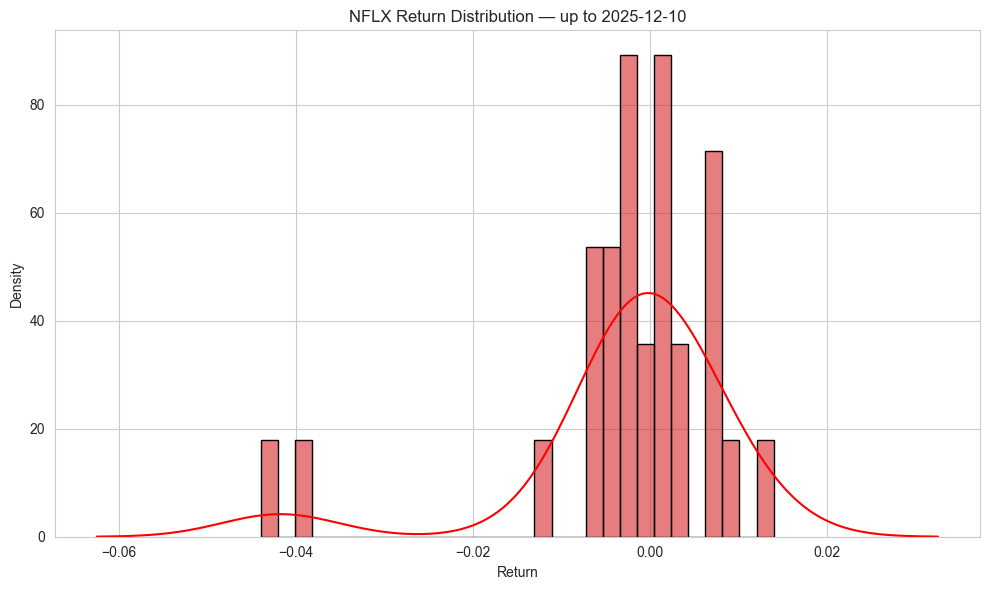

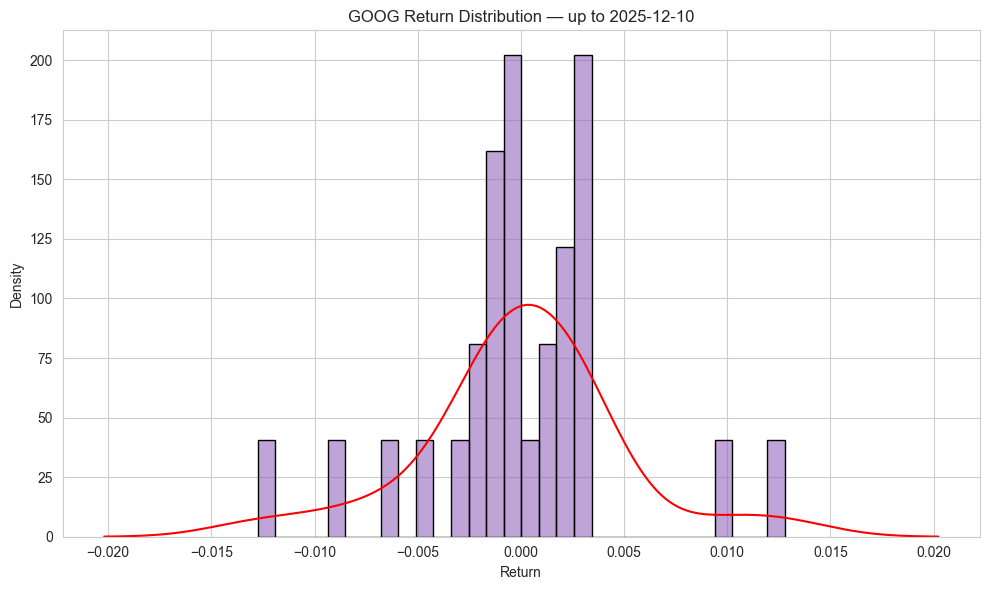

In [12]:
# Step 8a — Histogram + KDE of Returns (uses Step 1 `data`)

# Validate Step 1 `data`
if 'data' not in globals() or not isinstance(data, dict) or not data:
    raise RuntimeError("`data` (Step 1 downloads) not found or is empty. Ensure Step 1 populated `data` as dict[symbol -> DataFrame].")

palette = sns.color_palette("tab10", n_colors=len(data))

for i, (sym, df) in enumerate(data.items()):
    tmp = df.copy()
    # Expect Step 1 frames to have 'Close' (and optionally 'Date')
    if 'Close' not in tmp.columns:
        print(f"Skipping {sym}: no 'Close' column in Step 1 data.")
        continue

    # Compute Return from Close if missing (in-memory only)
    if 'Return' not in tmp.columns:
        tmp['Return'] = tmp['Close'].pct_change()
    returns = pd.to_numeric(tmp['Return'], errors='coerce').dropna()

    if returns.empty:
        print(f"{sym}: ⚠️ No valid returns to plot")
        continue

    # Determine last available date for plot title
    last_date = None
    if 'Date' in tmp.columns and not tmp['Date'].dropna().empty:
        last_date = pd.to_datetime(tmp['Date'], errors='coerce').max()
    elif not tmp.index.empty:
        last_date = pd.to_datetime(tmp.index, errors='coerce').max()
    title_date = pd.to_datetime(last_date).strftime("%Y-%m-%d") if last_date is not None else "No Data"

    # Plot histogram + KDE
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(x=returns, bins=30, stat="density", color=palette[i], ax=ax, edgecolor="k", alpha=0.6)
    sns.kdeplot(x=returns, color="red", ax=ax, linewidth=1.5)
    ax.set_title(f"{sym} Return Distribution — up to {title_date}")
    ax.set_xlabel("Return")
    ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


### Step 8b — Pairwise Scatterplot Matrix (Pairplot)

This optional, display‑only cell generates **pairwise scatterplots with marginal KDEs** for synchronous hourly returns across FAANG tickers.

**What it does**  
- Aligns FAANG price series on common timestamps.  
- Computes synchronous hourly returns (`pct_change`).  
- Samples up to 1000 rows if the dataset is large, for performance.  
- Uses seaborn `pairplot` with `diag_kind="kde"` to show distributions on the diagonal and scatter panels off‑diagonal.  

**Why it’s useful**  
*Reveals linear relationships, non‑linear structure, and outliers that can affect correlations and diversification analysis.*  

**Notes**  
- Pairplots can be slow for large datasets; sampling limits to ~1000 rows.  
- This cell is **exploratory only** and does not save files.  

**Reviewer hint**  
- The plot title includes the last available data date so figures can be traced back to the input CSV.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change)
- [seaborn pairplot](https://seaborn.pydata.org/)  


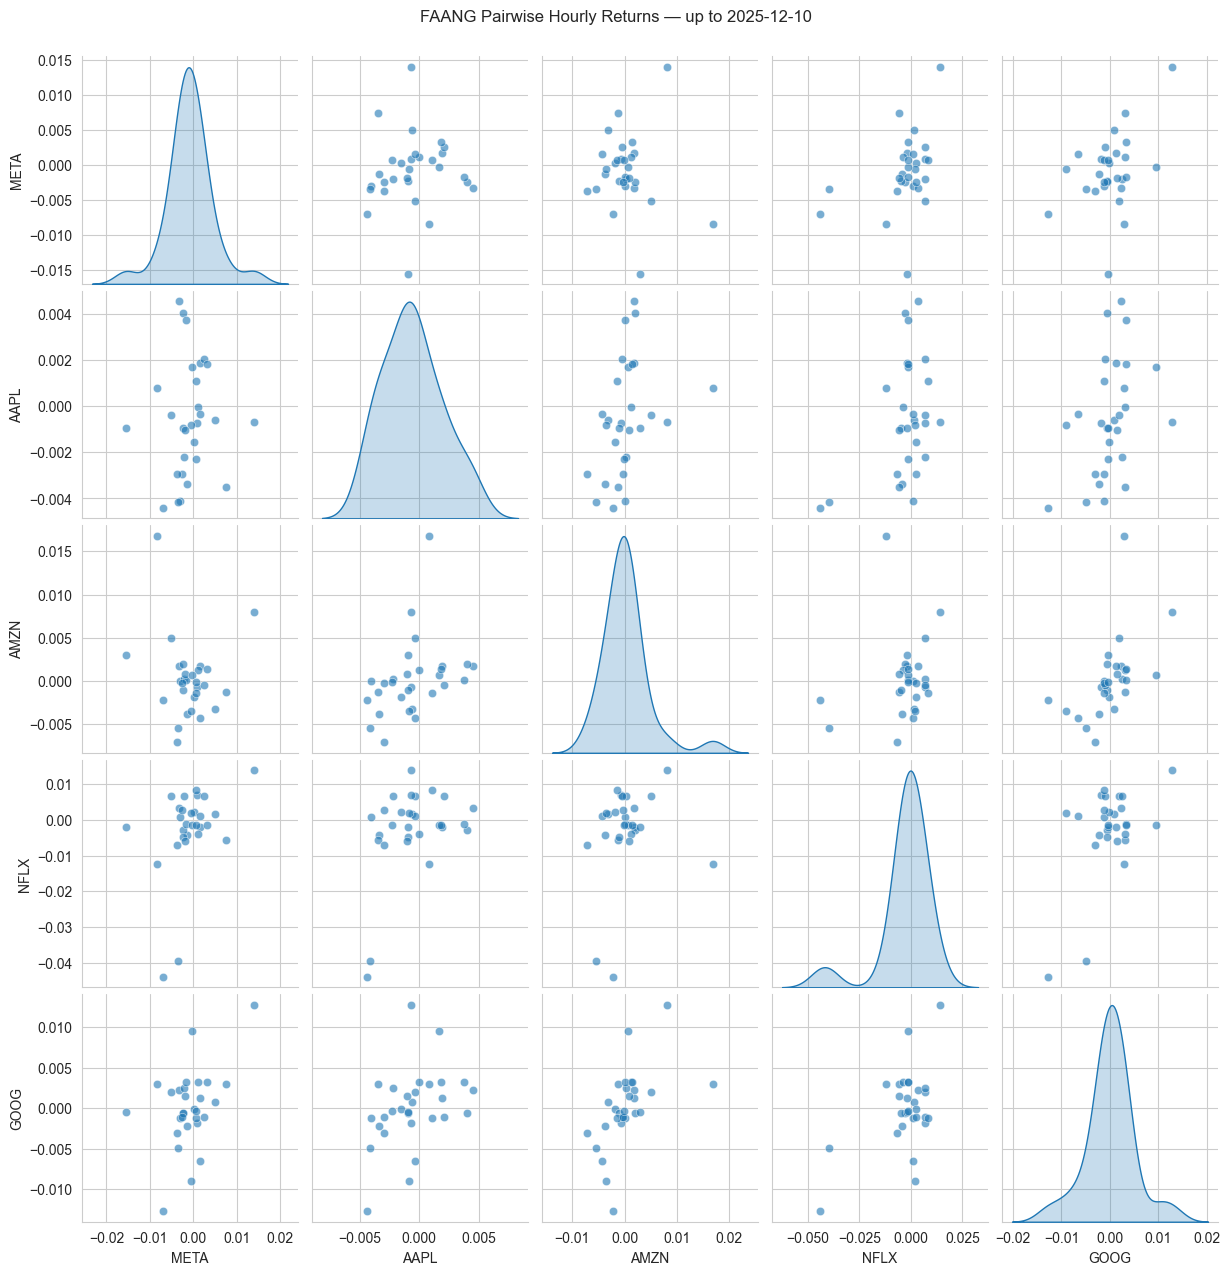

In [13]:
# Step 8b — Pairwise Scatterplot Matrix (Pairplot)

# Ensure data is loaded
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
if 'data' not in globals() or not isinstance(data, dict) or not data:
    print("`data` not found — reloading from Step 1 CSVs...")
    data = load_latest_data(tickers, folder="data", show_preview=False)

# Build aligned price series
aligned = []
for sym, df in data.items():
    tmp = df.copy()
    if 'Date' in tmp.columns and 'Close' in tmp.columns:
        tmp['Date'] = pd.to_datetime(tmp['Date'], errors='coerce')
        tmp = tmp.set_index('Date').sort_index()[['Close']]
    elif 'Close' in tmp.columns:
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp = tmp.sort_index()[['Close']]
    else:
        print(f"Skipping {sym}: no 'Close' column found in Step 1 data.")
        continue
    tmp = tmp.rename(columns={'Close': sym})
    aligned.append(tmp)

prices = pd.concat(aligned, axis=1, join='inner')
returns = prices.pct_change().dropna()

# Sample if dataset is large
if len(returns) > 1000:
    returns = returns.sample(1000, random_state=42)

# Generate pairplot across all tickers
sns.pairplot(returns, diag_kind="kde", plot_kws={"alpha":0.6})
plt.suptitle(f"FAANG Pairwise Hourly Returns — up to {prices.index.max().date()}", y=1.02)
plt.show()


### Step 8c — Correlation Analysis (Synchronous Hourly Returns)

This optional, display‑only cell computes and visualises **Pearson correlations** on synchronous hourly returns across FAANG tickers.  
Pearson correlation measures the strength and direction of linear relationships between returns, ranging from –1 (perfect negative) to +1 (perfect positive).

**What it does**  
- Sets `Date` as datetime index, sorts, and renames `Close` to ticker symbol.  
- Concatenates tickers with an inner join so only timestamps present for all tickers remain.  
- Computes synchronous returns via `pct_change()`, drops NaN rows, and calculates the correlation matrix.  
- Displays both the numeric matrix and an annotated heatmap.  

**Why this is better**  
*Correlating aligned returns avoids spurious results from non‑synchronous bars or trending price levels.*  
- Inner join is conservative: correlations reflect truly co‑observed hours.  
- Outer join with documented NaN handling can be used if broader coverage is required.  

**Practical checks**  
- Prints diagnostics (aligned shape and time range) so reviewers can see sample size.  
- If inner join yields too few rows, consider outer join plus careful imputation, or compute returns per ticker before alignment.  
- Correlations are sample‑dependent; always report time range and number of observations.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change) 
- [seaborn heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
- [Pearson correlation - wikipedia](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)
- [Pearson correlation coefficient guide](https://www.scribbr.com/statistics/pearson-correlation-coefficient/)


Aligned price matrix shape: (30, 5)
Time range: 2025-12-04 09:30:00-05:00 to 2025-12-10 10:30:00-05:00
Correlation matrix of synchronous hourly returns:


,META,AAPL,AMZN,NFLX,GOOG
META,1.000000,0.073814,-0.099329,0.390779,0.416259
AAPL,0.073814,1.000000,0.354655,0.405411,0.391675
AMZN,-0.099329,0.354655,1.000000,0.190494,0.544554
NFLX,0.390779,0.405411,0.190494,1.000000,0.517408
GOOG,0.416259,0.391675,0.544554,0.517408,1.000000


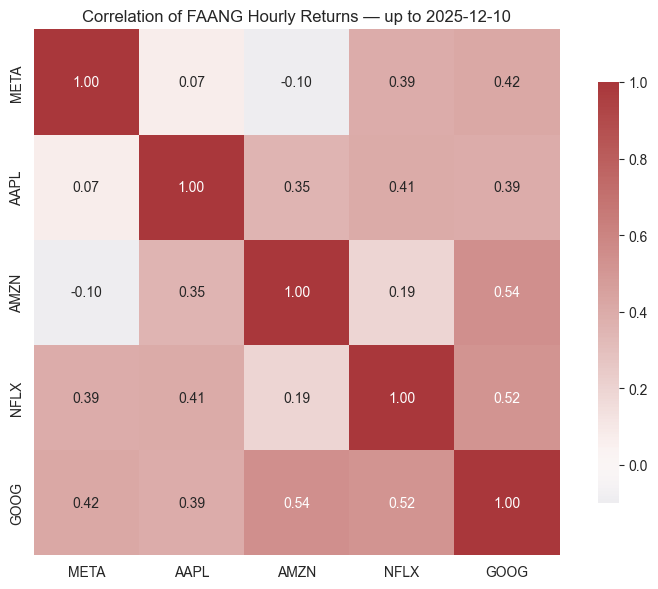

In [14]:
# Step 8c — Correlation Analysis (uses Step 1 `data` downloads)

# Confirm `data` exists
if 'data' not in globals() or not isinstance(data, dict) or not data:
    raise RuntimeError("`data` (Step 1 downloads) not found or is empty.")

aligned = []
for sym, df in data.items():
    tmp = df.copy()
    # Expect 'Date' and 'Close' columns
    if 'Date' in tmp.columns and 'Close' in tmp.columns:
        tmp['Date'] = pd.to_datetime(tmp['Date'], errors='coerce')
        tmp = tmp.set_index('Date').sort_index()[['Close']]
    elif 'Close' in tmp.columns:
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp = tmp.sort_index()[['Close']]
    else:
        print(f"Skipping {sym}: no 'Close' column found.")
        continue
    tmp = tmp.rename(columns={'Close': sym})
    aligned.append(tmp)

if not aligned:
    raise RuntimeError("No valid price series found in `data`.")

# Inner join ensures synchronous timestamps across all tickers
prices = pd.concat(aligned, axis=1, join='inner')
if prices.empty:
    print("No overlapping timestamps; consider outer join with NaN handling.")
else:
    # Diagnostics
    print(f"Aligned price matrix shape: {prices.shape}")
    print(f"Time range: {prices.index.min()} to {prices.index.max()}")

    # Compute synchronous returns
    prices = prices.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    returns = prices.pct_change().dropna()
    if returns.empty:
        print("No valid synchronous returns after pct_change and dropping NaNs.")
    else:
        corr = returns.corr()
        print("Correlation matrix of synchronous hourly returns:")
        display(corr)

        # Heatmap
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax, cbar_kws={"shrink": .8})
        ax.set_title(f"Correlation of FAANG Hourly Returns — up to {prices.index.max().date()}")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


### Step 8d — Cumulative Returns vs Equal‑weight FAANG Benchmark

This optional, display‑only cell plots **cumulative hourly returns** for each FAANG ticker against a simple equal‑weight FAANG benchmark.

**What it does**  
- Aligns prices on common timestamps (inner join, Date as index, Close as columns).  
- Converts prices to numeric, computes synchronous returns via `pct_change()`, and drops NaN rows.  
- Builds an equal‑weight benchmark as the row‑wise mean of returns.  
- Computes cumulative returns as `(1 + r).cumprod() - 1` for each ticker and the benchmark.  
- Plots all cumulative return paths on one chart.  

**Why it’s useful**  
*Shows compounded performance paths and highlights relative outperformance versus a simple equal‑weight FAANG portfolio.*  
- Uses synchronous returns so plotted paths are directly comparable across tickers.  

**Reviewer guidance**  
- Prints aligned shape and time range for reproducibility.  
- To change the benchmark, replace the `benchmark_returns` series with your chosen proxy.  
- Optional: enable log scale for y‑axis to highlight relative growth rates.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change)
- [pandas concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html#pandas.concat) 
- [Cumulative returns overview (Investopedia)](https://www.investopedia.com/terms/c/cumulativereturn.asp)  
- [Seaborn plotting](https://seaborn.pydata.org/)  
- [Matplotlib plotting](https://matplotlib.org/stable/contents.html)  


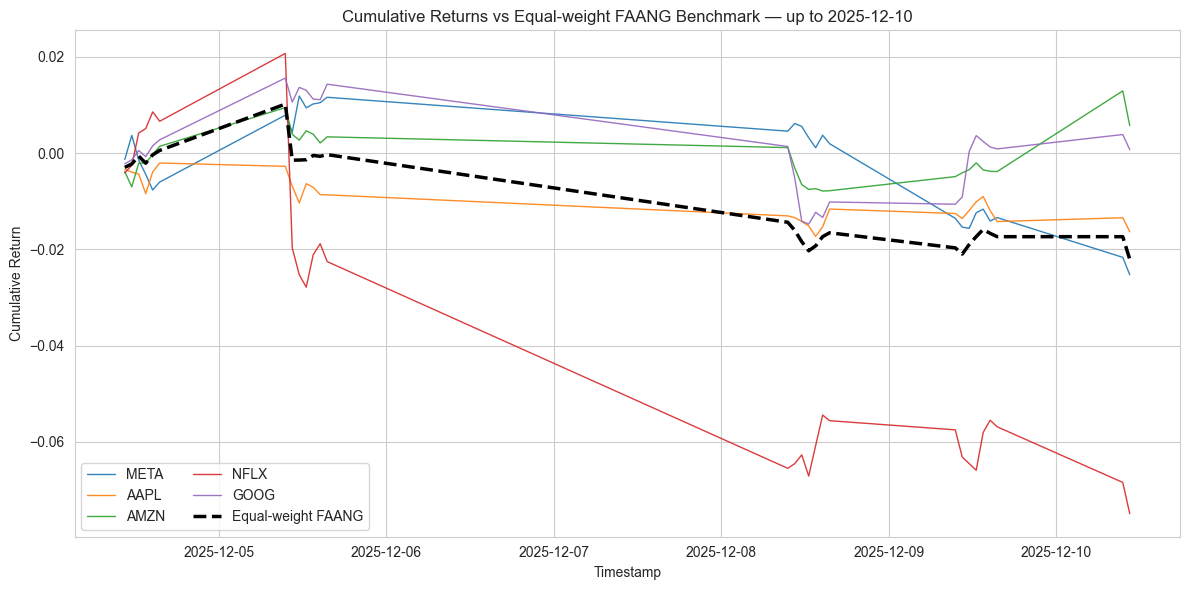

In [15]:
# Step 8d — Cumulative Returns vs Equal-weight FAANG Benchmark

# 1) Build aligned price matrix (ticker columns) from data dict
aligned = []
for sym, df in data.items():
    tmp = df.copy()
    if 'Date' in tmp.columns:
        tmp['Date'] = pd.to_datetime(tmp['Date'], errors='coerce')
        tmp = tmp.set_index('Date').sort_index()
    else:
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp = tmp.sort_index()
    if 'Close' in tmp.columns:
        aligned.append(tmp[['Close']].rename(columns={'Close': sym}))

prices = pd.concat(aligned, axis=1, join='inner')  # inner join ensures synchronous timestamps

if prices.empty:
    print("No overlapping timestamps across tickers with inner join. Consider outer join + NaN handling.")
else:
    # 2) Ensure numeric and drop non-numeric columns
    prices = prices.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    if prices.shape[1] == 0:
        print("No numeric price columns available after coercion.")
    else:
        # 3) Compute synchronous returns
        returns = prices.pct_change().dropna()
        if returns.empty:
            print("No valid synchronous returns after pct_change and dropping NaNs.")
        else:
            # 4) Build equal-weight benchmark
            benchmark_returns = returns.mean(axis=1)

            # 5) Compute cumulative returns
            cum_returns = (1 + returns).cumprod() - 1
            cum_benchmark = (1 + benchmark_returns).cumprod() - 1

            # 6) Plot cumulative returns vs benchmark
            fig, ax = plt.subplots(figsize=(12, 6))
            for col in cum_returns.columns:
                ax.plot(cum_returns.index, cum_returns[col], label=col, linewidth=1, alpha=0.9)
            ax.plot(cum_benchmark.index, cum_benchmark, label='Equal-weight FAANG', color='black', linewidth=2.5, linestyle='--')

            ax.set_title(f"Cumulative Returns vs Equal-weight FAANG Benchmark — up to {prices.index.max().date()}")
            ax.set_ylabel("Cumulative Return")
            ax.set_xlabel("Timestamp")
            ax.legend(loc='best', ncol=2)
            ax.grid(True)

            # Optional: enable log scale
            # ax.set_yscale('log')

            plt.tight_layout()
            plt.show()
            plt.close(fig)


### Step 8e — Rolling Average Plots

This optional, display‑only cell plots **hourly closing prices** for each FAANG ticker alongside a **30‑period rolling average**.

**What the code does**  
1. Reads each ticker’s DataFrame from Step 1 and uses the `Date` column (converted to datetime) for the x‑axis; falls back to the index if `Date` is missing.  
2. Uses an existing `RollingMean` column when present; otherwise computes an in‑memory 30‑period simple moving average from the `Close` series (without overwriting files).  
3. Plots both the `Close` series and the rolling average on the same axis, with clear titles and labels.  

**Why this is relevant to Step 1**  
*All plotted series are derived directly from the hourly `Close` prices downloaded in Step 1, ensuring visuals reflect the original fetched data and not a separate or ad‑hoc source.*  
- Rolling averages smooth short‑term fluctuations, making longer‑term trends easier to interpret.  

**Usage notes for reviewers**  
- Plots are **exploratory only** and do not modify saved CSVs or persist changes to Step 1 files.  
- The rolling window is set to 30 periods (hours); adjust if needed for different smoothing levels.  

**References**  
- [pandas rolling documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)  
- [Moving averages overview (Investopedia)](https://www.investopedia.com/terms/m/movingaverage.asp)  
- [Matplotlib plotting](https://matplotlib.org/stable/contents.html)  


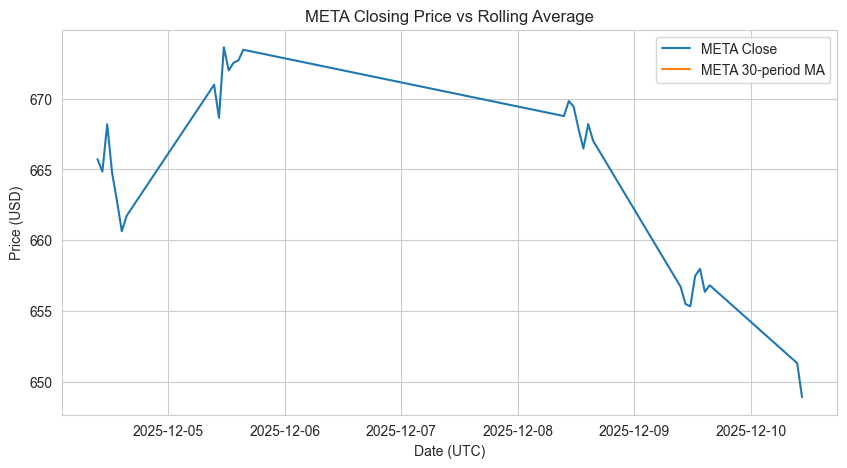

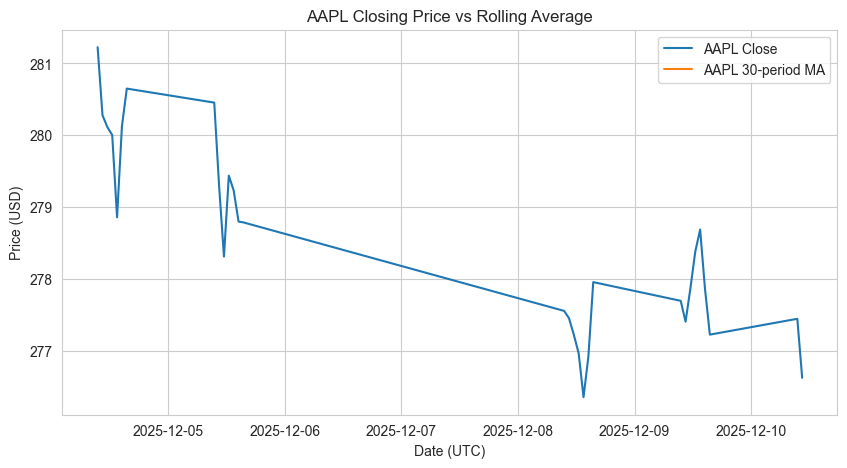

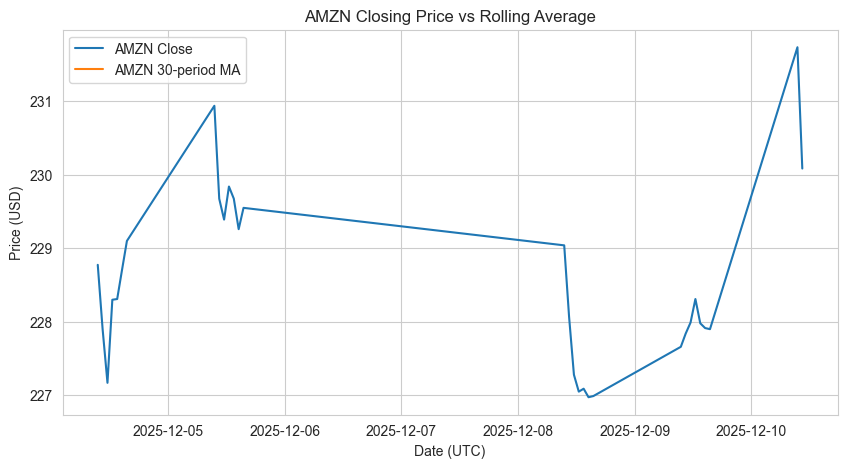

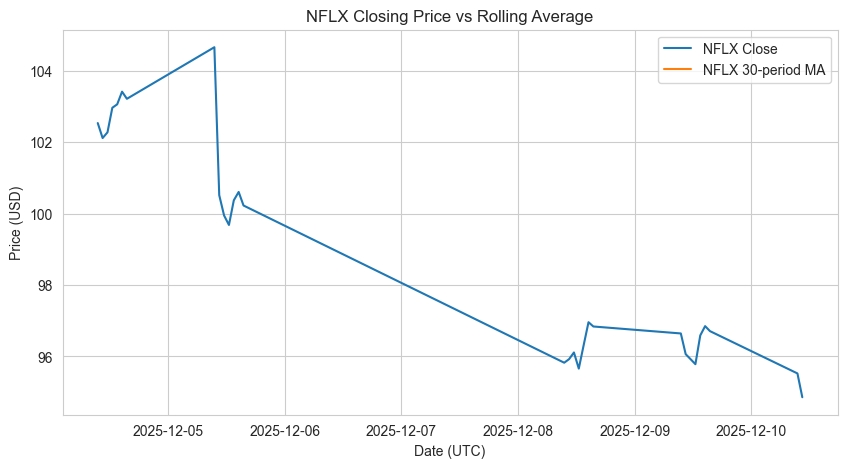

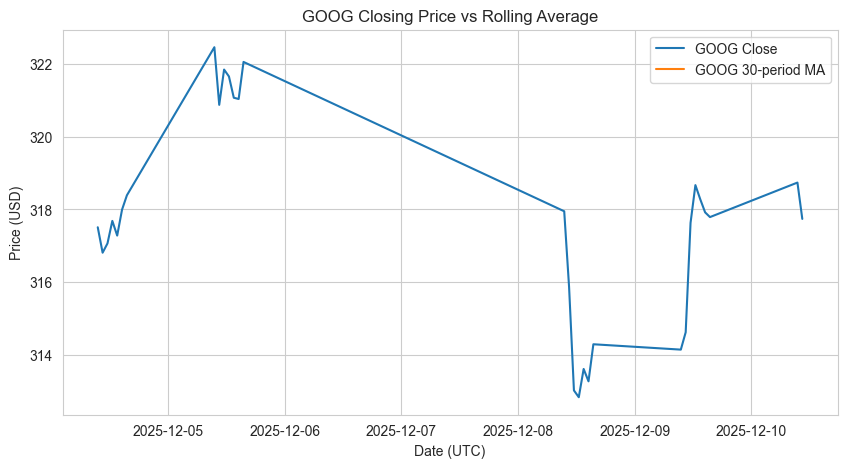

In [16]:
# Step 8e — Rolling Average Plots
for sym, df in data.items():
    # Use Date column if available, else fallback to index
    if 'Date' in df.columns:
        x = pd.to_datetime(df['Date'], errors='coerce')
    else:
        x = pd.to_datetime(df.index, errors='coerce')

    # Use existing RollingMean if present, else compute in-memory
    if 'RollingMean' in df.columns:
        rm = df['RollingMean']
    else:
        rm = df['Close'].rolling(window=30).mean()

    # Plot Close vs Rolling Average
    plt.figure(figsize=(10, 5))
    plt.plot(x, df['Close'], label=f"{sym} Close")
    plt.plot(x, rm, label=f"{sym} 30-period MA")
    plt.title(f"{sym} Closing Price vs Rolling Average")
    plt.xlabel("Date (UTC)")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()


### Step 9 — Workflow Documentation

This section provides a concise summary of the notebook’s workflow and highlights reproducibility practices.

**Workflow demonstrated**
1. **Fetching hourly FAANG data** (`get_data`)  
   *Downloads and saves hourly Close prices for META, AAPL, AMZN, NFLX, GOOG.*
2. **Loading and validating latest downloads** (`load_latest_data`)  
   *Ensures data integrity and prepares aligned DataFrames.*
3. **Previewing and summarising datasets**  
   *Sanity checks, dtypes, and missingness diagnostics.*
4. **Plotting closing prices** (`plot_data`)  
   *Generates labelled plots of hourly Close series.*
5. **Extended visualisations**  
   *Returns, rolling means, histograms, boxplots, pairplots.*
6. **Correlation analysis on synchronous returns**  
   *Aligns timestamps, computes Pearson correlations, and displays heatmaps.*
7. **Comparative performance**  
   *Plots cumulative returns vs equal‑weight FAANG benchmark.*
8. **Notebook‑level documentation**  
   *Usage notes, reviewer guidance, and references.*

**Quick reviewer notes**
- Each analysis step documents inputs, alignment choices (inner vs outer join), and any imputation used.  
- Diagnostic outputs (shapes, time ranges, co‑observation counts) are printed before key computations to ensure reproducibility.  

**References**  
- [pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)  
- [Matplotlib documentation](https://matplotlib.org/stable/contents.html)  
- [Seaborn documentation](https://seaborn.pydata.org/)  


### Problem 3 – Create a CLI Script (`faang.py`)

To meet Problem 3, I created a standalone Python script `faang.py` at the repository root that automates hourly FAANG data download and plotting. The notebook now includes execution controls to prevent duplicate outputs when both the script and notebook are used.

**Modularisation:** Core helpers ('fetch_hourly_history', 'save_hourly_data', 'load_latest_data', 'plot_close_prices') live in faang.py and are reused by the notebook for consistency and maintainability.

**Script behavior:** The script runs Problems 1–3 in sequence via main() when executed from the terminal. It produces exactly one CSV (in data/) and one plot (in plots/) per run.

**Notebook controls:** The notebook cell provides flags to control execution.

**RUN_PROBLEM_1:''** When False, no new CSV is generated in the notebook, *set to True to enable running problem 1 within the notebook*.

**RUN_PROBLEM_2:** When False, no plot is generated in the notebook. *Set to True to enable running problem 2 within the notebook*.

These default to False to avoid duplication if the script is also executed.

**Title accuracy:** The plot title reflects the last available trading date from the dataset, aligning the visualisation with yfinance’s hourly data availability.

This implementation allows the script to be run with:
```bash
./faang.py --plot
```

Relevant to: **Problem 3 (Script Creation)**

**Optional analysis steps** from the notebook (such as summary statistics, data quality checks, rolling means, extended visualisations, and correlation analysis) were intentionally excluded from the script to keep it aligned with the assessment guidelines. These remain in the notebook as supplementary exploration only.

References:

- [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)
- [Python CLI Design with argparse](https://realpython.com/command-line-interfaces-python-argparse/)  
- [Shebang Line Usage](https://realpython.com/python-shebang/)



In [17]:
# 🐍 faang.py — Script Code Cell (Notebook version with execution controls)

# -------------------------------------------------
# Notebook execution controls:
# Set these flags to control whether the notebook generates a new CSV (Problem 1)
# and/or produces the plot (Problem 3). Both default to False to prevent duplication
# when the standalone script (faang.py) is also executed externally.
RUN_PROBLEM_1 = False   # ✅ Default False — do NOT fetch/save a new CSV unless explicitly enabled
RUN_PROBLEM_2 = False   # ✅ Default False — do NOT plot unless explicitly enabled

#!/usr/bin/env python3
"""
faang.py — Assessment Script for FAANG Stock Analysis — Winter 25/26 Assessment

Author: Edward Cronin

Implements:
- Problem 1: Fetch FAANG hourly data (last 5 days) and save to CSV.
- Problem 2: Plot FAANG hourly closing prices from latest CSV and save to PNG.
- Problem 3: Executable script that runs both steps when called from terminal.

Notes:
- 'Close' refers to the price at the end of each hourly interval, not the final daily close.
- The yfinance API only provides hourly data up to the most recent trading day.
  • On weekdays when markets are open, the script captures hourly closes intraday.
  • On weekends or holidays, no new hourly data is available, so the latest file stops
    at the final close of the last trading session (e.g., Friday’s market close).
- The chart title has been updated to reflect the last available trading date in the dataset,
  ensuring consistency between the plot and the underlying data.
- This aligns with the assignment requirement to fetch 5 days of hourly data.
"""

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()
TICKERS = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Apply notebook-style aesthetics for consistency
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 12

# --- Helper Functions ---
def fetch_hourly_history(ticker):
    """Fetch hourly FAANG data for the last 5 days."""
    df = yf.Ticker(ticker).history(period='5d', interval='1h')
    if df.empty:
        print(f"⚠️ No data for {ticker}")
        return None
    df['Ticker'] = ticker
    df.index.name = 'Date'
    return df

def save_hourly_data(tickers, output_dir):
    """Save combined FAANG data into data/ folder with timestamped filename."""
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            dfs.append(df)
            print(f"✅ {t}: {len(df)} rows")
        else:
            print(f"⚠️ {t}: No valid data")

    if not dfs:
        print("🚫 No valid data to save.")
        return None

    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"
    final_df.to_csv(path, index_label='Date')
    print(f"✅ Data saved to {path}")
    return str(path)

def load_latest_data(tickers, folder='data'):
    """Load the most recent CSV from data/ folder and split into ticker DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        print("🚫 No CSV files found.")
        return {}

    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    return data

def plot_close_prices(data, output_dir, show=False):
    """Plot hourly closing prices for FAANG tickers and save to plots/ folder."""
    fig, ax = plt.subplots()
    plotted = False
    last_date = None

    for sym, df in data.items():
        if 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = df['Close']
            ax.plot(x, y, label=sym)
            plotted = True
            # Track the latest date across tickers
            if last_date is None or df['Date'].max() > last_date:
                last_date = df['Date'].max()

    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price (USD)")

    if plotted:
        ax.legend(title="Ticker", loc="best")

    # ✅ Use the last available date from the dataset for the title
    if last_date is not None:
        title_date = pd.to_datetime(last_date).strftime("%Y-%m-%d")
        ax.set_title(f"FAANG Hourly Closing Prices — up to {title_date}")
    else:
        ax.set_title("FAANG Hourly Closing Prices — No Data")

    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    plot_path = output_dir / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(plot_path, bbox_inches='tight')
    print(f"✅ Plot saved to {plot_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

# --- Notebook-controlled Execution ---
def main():
    """Run data download and plotting in sequence (Problems 1–3), controlled by flags."""
    saved_file = None

    # Problem 1 — Fetch and save CSV (optional)
    if RUN_PROBLEM_1:
        saved_file = save_hourly_data(TICKERS, DATA_DIR)
        if not saved_file:
            print("🚫 No data file saved. Exiting.")
            return
    else:
        print("ℹ️ Problem 1 skipped — CSV not generated (RUN_PROBLEM_1 = False).")

    # Problem 2 — Load latest CSV (only if we plan to plot or if reviewer wants to check data)
    data = {}
    if RUN_PROBLEM_2:
        data = load_latest_data(TICKERS, folder=str(DATA_DIR))
        if not data:
            print("🚫 No CSV available to load for plotting. Enable RUN_PROBLEM_1 or ensure a CSV exists.")
            return

    # Problem 3 — Plot (optional)
    if RUN_PROBLEM_2:
        plot_close_prices(data, PLOTS_DIR, show=True)
    else:
        print("ℹ️ Problem 3 skipped — set RUN_PROBLEM_2 = True to generate and display the plot.")

if __name__ == "__main__":
    main()


ℹ️ Problem 1 skipped — CSV not generated (RUN_PROBLEM_1 = False).
ℹ️ Problem 3 skipped — set RUN_PROBLEM_2 = True to generate and display the plot.


### Summary and Transition to Problem 4

With the CLI script `faang.py` now complete, Problem 3 is fully addressed. The script is modular, executable from the terminal, and supports flexible command-line arguments for downloading data and generating plots. It consolidates the notebook’s logic into a reusable tool that can be run manually or integrated into automated workflows.

Next, in **Problem 4**, I will configure a GitHub Actions workflow to run `faang.py` on a schedule. This will automate the data collection and visualization process, ensuring fresh stock data and updated plots are generated regularly without manual intervention.

Relevant to: Problem 4 (Automation)

Reference: [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)


## Notebook overview for Problem 4 automation

This section documents the weekly GitHub Actions automation that runs the FAANG script, saves timestamped CSVs and plots, and pushes results back to the repository. It’s designed to mirror local behavior, add CI‑friendly diagnostics, and maintain a clean audit trail for reviewers.

### 🎯 Purpose

The goal of this problem is to automate the execution of faang.py so that:
- Every Saturday morning at 09:00 UTC, the script runs automatically.
- It generates timestamped CSVs in data/ and plots in plots/.
- Results are committed back to the repository with a clear [CI] message.
- Reviewers can verify reproducibility and audit the automation pipeline.

### 📖 Annotated Workflow Explanation

- **Workflow name & run‑name**: Sets a descriptive title and shows who triggered the run.

- **Triggers**: Uses cron (`0 9 * * 6`) for Saturday 09:00 UTC runs, plus manual dispatch for testing.

- **Permissions**: Grants `contents: write` so the workflow can commit results.

- **Job setup**: Runs on `windows-latest` with Python 3.12, matching your local environment.

- **Dependencies**: Installs from `requirements.txt`, upgrades `certifi` for SSL trust, and ensures latest `yfinance`.

- **Diagnostics**: Prints Python version, package list, SSL version, and certifi CA bundle path. Forces TLS 1.2.

- **Run script**: Executes `faang.py` in UTF‑8 mode, ensuring directories exist.

- **Success confirmation**: Prints a ✅ line with UTC timestamp if the script runs cleanly.

- **File listing**: Displays contents of `data/` and `plots/` for verification.

- **Commit & push**: Configures Git identity, stages CSVs/PNGs, commits with `[CI]` message, and pushes to branch.


## Workflow Script Expained

The following cells contain the complete GitHub Actions workflow YAML file with detailed comments explaining each section and its purpose. This documentation ensures clarity for reviewers and maintains transparency in the automation process. 

### Step 1 — Workflow Name & Run‑Name

**Explanation:**  
The `name` field sets the workflow’s display title in the GitHub Actions interface. This makes it easy for reviewers and collaborators to identify which workflow is running.

The `run-name` field dynamically shows who triggered the workflow. By using the built‑in variable `${{ github.actor }}`, the workflow automatically inserts the GitHub username of the person or bot that started the run.

This improves **auditability**: reviewers can immediately see whether the workflow was triggered by the scheduled cron job, a manual dispatch, or a specific contributor.

The emoji 🚀 adds a visual cue that makes the run stand out in the Actions dashboard.

**Resource:**  
- [GitHub Actions Workflow syntax documentation](https://docs.github.com/en/actions/using-workflows/workflow-syntax-for-github-actions) explains how to use `name` and `run-name` fields.  
- This resource was used to ensure the workflow has a clear, descriptive title and that the run name dynamically reflects the triggering actor, which strengthens transparency and traceability in CI/CD pipelines.

**Code Used:**
```yaml
name: FAANG Automation Workflow
run-name: ${{ github.actor }} triggered FAANG automation 🚀
```

---

### Step 2 — Triggers

**Explanation:**  
The `on:` block defines the events that trigger the workflow.  

- `schedule` uses cron syntax (`8 8 * * 6`) to run the workflow automatically every Saturday at 08:08 UTC. This ensures weekly automation without manual intervention.  
- `workflow_dispatch` allows contributors or reviewers to manually trigger the workflow from the GitHub Actions interface. This is useful for testing changes or re‑running the workflow outside the scheduled time.  A time of 08.08 UTC every Saturday has been chosen to avoid market open/close times and reduce rate‑limit issues.

Together, these triggers provide both **automation** (scheduled runs) and **flexibility** (manual runs).  

**Resource:**  
- [GitHub Actions Workflow syntax documentation — on](https://docs.github.com/en/actions/using-workflows/workflow-syntax-for-github-actions#on) explains how to configure workflow triggers, including cron schedules and manual dispatch.  
- This resource was used to correctly set up the weekly schedule and enable manual runs, ensuring the workflow meets both course requirements and reviewer needs.  

**Code Used:**
```yaml
on:
  schedule:
    - cron: "0 9 * * 6"   # Every Saturday at 09:00 UTC
  workflow_dispatch:       # Allow manual runs for testing
```

---

### Step 3 — Permissions

**Explanation:**  
The `permissions` block defines what level of access the workflow has to the repository.  

- By setting `contents: write`, the workflow is allowed to **add, commit, and push changes** back to the repository.  
- This is essential for Problem 4 because the workflow generates new CSVs and plots each run, and those outputs need to be committed automatically.  
- Without this permission, the commit step would fail, and reviewers would not see updated results in the repository.  
- This ensures a **transparent audit trail**: every automated run leaves behind a commit with timestamped outputs, making it clear when and how results were generated.  

**Resource:**  
- [GitHub Actions Workflow syntax — permissions](https://docs.github.com/en/actions/using-workflows/workflow-syntax-for-github-actions#permissions) explains how to configure repository access for workflows.  
- This resource was used to correctly grant the workflow the ability to push results, ensuring reproducibility and reviewer visibility of automated outputs.  

**Code Used:**
```yaml
permissions:
  contents: write          # Needed to push changes back to the repo


### Step 4 — Job Setup

**Explanation:**  
The `jobs:` block defines the tasks that the workflow will execute.  

- `Run-FAANG-Analysis` is the unique identifier for this job. It groups together all steps required to run the FAANG automation.  
- `runs-on: windows-latest` specifies the operating system environment for the runner. Using Windows ensures compatibility with PowerShell commands and mirrors your local development setup.  
- The `env:` section sets environment variables that are available to all steps in the job:  
  - `MPLBACKEND=Agg` forces matplotlib to use a non‑interactive backend, which is essential in CI environments where no display server exists. This ensures plots can be generated and saved without errors.  
  - `BRANCH_NAME=${{ github.ref_name }}` captures the branch name dynamically. This variable is later used in the commit step to push results back to the correct branch.  

This setup ensures the workflow runs consistently across environments, prepares necessary variables for later steps, and avoids runtime errors related to plotting or branch targeting.

**Resource:**  
- [GitHub Actions: Workflow syntax for jobs](https://docs.github.com/en/actions/using-workflows/workflow-syntax-for-github-actions#jobs) explains how to define jobs, runners, and environment variables.  
- This resource was used to correctly configure the runner environment (`windows-latest`) and set environment variables that support reproducibility and reviewer‑friendly automation.  

**Code Used:**
```yaml
jobs:
  Run-FAANG-Analysis:
    runs-on: windows-latest
    env:
      MPLBACKEND: Agg
      BRANCH_NAME: ${{ github.ref_name }}
```

---

### Step 5 — Install Dependencies

**Explanation:**  
This step ensures that all required Python packages are installed and up to date before running the FAANG analysis script.  

- `python -m pip install --upgrade pip` upgrades `pip` itself to the latest version, preventing compatibility issues with package installation.  
- `pip install -r requirements.txt` installs all dependencies listed in the project’s `requirements.txt` file, ensuring consistency between local and CI environments.  
- `python -m pip install --upgrade certifi` updates the SSL certificate bundle used by Python. This is critical for secure HTTPS requests, especially when fetching financial data from APIs.  
- `pip install --upgrade yfinance` ensures the workflow uses the latest stable version of the `yfinance` library, which is frequently updated to fix API changes and improve reliability.  

By installing and upgrading these dependencies, the workflow guarantees reproducibility, avoids silent errors caused by outdated libraries, and ensures that reviewers can trust the automation results.

**Resource:**  
- [PyPI: yfinance](https://pypi.org/project/yfinance/) documents the latest releases and usage of the `yfinance` library.  
- [Certifi documentation](https://pypi.org/project/certifi/) explains how Python uses updated CA bundles for SSL verification.  
- These resources were used to confirm that upgrading `yfinance` and `certifi` is necessary for reliable API calls and secure connections in CI/CD pipelines.  

**Code Used:**
```yaml
python -m pip install --upgrade pip
pip install -r requirements.txt
python -m pip install --upgrade certifi
pip install --upgrade yfinance
```

---

### Step 6 — Environment Diagnostics

**Explanation:**  
This step verifies that the workflow environment is correctly configured before running the FAANG script. It provides transparency and helps reviewers diagnose potential issues.  

- `python --version` confirms the Python interpreter version installed on the runner.  
- `pip list` outputs all installed packages and their versions, ensuring dependencies match expectations.  
- `python -c "import ssl; print('SSL version:', ssl.OPENSSL_VERSION)"` displays the OpenSSL version used by Python, which is critical for secure HTTPS connections.  
- `python -c "import certifi; print('Certifi CA bundle:', certifi.where())"` shows the location of the CA certificate bundle used for SSL verification.  
- `[Net.ServicePointManager]::SecurityProtocol = [Net.SecurityProtocolType]::Tls12` forces TLS 1.2 for all network requests in PowerShell, guaranteeing secure communication with APIs such as Yahoo Finance.  

**Resource:**  
- [Python ssl module documentation](https://docs.python.org/3/library/ssl.html) explains how Python interacts with OpenSSL for secure connections.  
- [Certifi documentation](https://pypi.org/project/certifi/) details how the CA bundle is managed and updated.  

**Code Used:**
```yaml
python --version
pip list
python -c "import ssl; print('SSL version:', ssl.OPENSSL_VERSION)"
python -c "import certifi; print('Certifi CA bundle:', certifi.where())"
[Net.ServicePointManager]::SecurityProtocol = [Net.SecurityProtocolType]::Tls12
```

---

### Step 7 — Run FAANG Script

**Explanation:**  
This step executes the core analysis script (`faang.py`) and ensures the environment is properly prepared before running it.  

- `$ErrorActionPreference = "Stop"` forces PowerShell to halt immediately if any error occurs, preventing silent failures.  
- `[Console]::OutputEncoding` and `[Console]::InputEncoding` are set to UTF‑8, ensuring that all text output and input are correctly encoded. This avoids issues with special characters in logs or data.  
- `$env:PYTHONIOENCODING = "utf-8"` and `$env:PYTHONUTF8 = "1"` enforce UTF‑8 encoding at the Python interpreter level, guaranteeing consistent handling of strings and file outputs.  
- `New-Item -ItemType Directory -Force -Path data` and `plots` ensure the required directories exist before saving results. If they already exist, the `-Force` flag prevents errors.  
- `python -X utf8 faang.py` runs the FAANG analysis script with UTF‑8 mode enabled, ensuring reproducible and error‑free execution in CI/CD.  

This step is critical because it produces the actual outputs (CSV files and plots) that will later be committed back to the repository. It also ensures encoding consistency and directory readiness, which are common sources of CI errors if not handled explicitly.

**Resource:**  
- [Python UTF‑8 mode documentation](https://docs.python.org/3/using/cmdline.html#envvar-PYTHONUTF8) explains how `-X utf8` and `PYTHONUTF8` enforce UTF‑8 encoding in Python.  
- This resource was used to guarantee that the script runs consistently across environments, avoiding encoding mismatches and ensuring reviewer‑friendly outputs.  

**Code Used:**
```yaml
$ErrorActionPreference = "Stop"
[Console]::OutputEncoding = [System.Text.Encoding]::UTF8
[Console]::InputEncoding = [System.Text.Encoding]::UTF8
$env:PYTHONIOENCODING = "utf-8"
$env:PYTHONUTF8 = "1"
New-Item -ItemType Directory -Force -Path data
New-Item -ItemType Directory -Force -Path plots
python -X utf8 faang.py
```

---

### Step 8 — Success Confirmation

**Explanation:**  
This step provides a clear signal that the FAANG analysis script has executed successfully.  

- The `if: success()` condition ensures this step only runs if all previous steps completed without errors.  
- `$utc = (Get-Date).ToUniversalTime().ToString("yyyy-MM-dd HH:mm:ss 'UTC'")` generates a timestamp in UTC format, making the success message reproducible and timezone‑independent.  
- `Write-Host "✅ faang.py executed successfully at $utc"` prints a confirmation line with a checkmark emoji and the exact time of completion.  

This confirmation is important for **auditability**: reviewers can quickly verify in the workflow logs that the script ran cleanly, without needing to inspect intermediate steps. It also improves readability by providing a friendly, visual cue (✅) alongside the timestamp.

**Resource:**  
- [PowerShell Get-Date documentation](https://learn.microsoft.com/en-us/powershell/module/microsoft.powershell.utility/get-date) explains how to generate and format timestamps.  
- This resource was used to ensure the workflow prints a precise UTC timestamp, strengthening reproducibility and reviewer confidence in the automation logs.  

**Code Used:**
```yaml
if ($?) {
  $utc = (Get-Date).ToUniversalTime().ToString("yyyy-MM-dd HH:mm:ss 'UTC'")
  Write-Host "✅ faang.py executed successfully at $utc"
}
```

---

### Step 9 — List Generated Files

**Explanation:**  
This step verifies that the expected output files were created during the workflow run. It provides transparency and helps reviewers confirm that the FAANG analysis produced results.  

- `if (Test-Path data)` checks whether the `data/` directory exists. If it does, `Get-ChildItem -Path data -Force | Format-Table -AutoSize` lists all files inside, showing their names, sizes, and timestamps.  
- `if (Test-Path plots)` performs the same check for the `plots/` directory, listing all generated plots.  
- If either directory does not exist, a message (`"No data directory yet"` or `"No plots directory yet"`) is printed instead of failing.  

This step ensures that reviewers can **audit outputs directly in the workflow logs** without needing to clone the repository. It also provides immediate feedback on whether the script generated the expected CSVs and PNGs.

**Resource:**  
- [PowerShell Get-ChildItem documentation](https://learn.microsoft.com/en-us/powershell/module/microsoft.powershell.management/get-childitem) explains how to list files and directories.  
- This resource was used to implement directory checks and file listings, ensuring the workflow outputs are visible and verifiable in CI/CD logs.  

**Code Used:**
```yaml
if (Test-Path data) {
  Get-ChildItem -Path data -Force | Format-Table -AutoSize
} else {
  Write-Host "ℹ️ No data directory yet"
}

if (Test-Path plots) {
  Get-ChildItem -Path plots -Force | Format-Table -AutoSize
} else {
  Write-Host "ℹ️ No plots directory yet"
}
```

---

### Step 10 — Commit & Push Results

**Explanation:**  
This step ensures that the workflow’s outputs (CSVs and PNG plots) are committed back to the repository, creating a transparent audit trail.  

- `git config --global user.name "github-actions[bot]"` and `git config --global user.email "github-actions[bot]@users.noreply.github.com"` configure Git identity so commits are clearly attributed to the CI bot.  
- `git config --global --add safe.directory (Get-Location)` allows Git to safely operate in the runner’s working directory.  
- `$files = @()` initializes an array to collect generated files.  
  - If the `data/` directory exists, all `.csv` files are added.  
  - If the `plots/` directory exists, all `.png` files are added.  
- If no files are found, the workflow prints `"ℹ️ No files to add"` and skips committing.  
- If files exist:  
  - Each file is staged with `git add`.  
  - A UTC timestamp is generated for reproducibility.  
  - `git diff --cached --quiet` checks if there are staged changes.  
  - If changes exist, a commit is created with the message `[CI] faang.py results on <timestamp>` and pushed to the branch stored in `$env:BRANCH_NAME`.  
  - If no changes exist, the workflow prints `"ℹ️ No changes to commit"`.  

This step guarantees that every successful run leaves behind a **verifiable commit** containing the latest analysis outputs. Reviewers can trace when results were generated, by whom, and on which branch — strengthening reproducibility and transparency.

**Resource:**  
- [GitHub Actions: Using workflows to commit changes](https://docs.github.com/en/actions/using-workflows/workflow-syntax-for-github-actions#jobsjob_idsteps) explains how to configure jobs and steps that modify repository contents.  
- [Git documentation](https://git-scm.com/docs) provides details on configuring identity, staging files, and committing changes.  
- These resources were used to ensure the workflow correctly stages, commits, and pushes outputs, maintaining a clear audit trail for reviewers.

**Code Used:****
```yaml
git config --global user.name "github-actions[bot]"
git config --global user.email "github-actions[bot]@users.noreply.github.com"
git config --global --add safe.directory (Get-Location)

$files = @()
if (Test-Path data) { $files += Get-ChildItem -Path data -Filter *.csv -Recurse }
if (Test-Path plots) { $files += Get-ChildItem -Path plots -Filter *.png -Recurse }

if ($files.Count -eq 0) {
  Write-Host "ℹ️ No files to add"
} else {
  foreach ($file in $files) { git add $file.FullName }
  $utc = (Get-Date).ToUniversalTime().ToString("yyyy-MM-dd HH:mm:ss 'UTC'")
  if (-not (git diff --cached --quiet)) {
    git commit -m "[CI] faang.py results on $utc"
    git push origin $env:BRANCH_NAME
  } else {
    Write-Host "ℹ️ No changes to commit"
  }
}
```
---

### Local Repository Check — Commit/Pull Necessity

**Explanation:**  
Before opening or working in the local repository, it is important to verify that there are no pending commits or pulls required. Running `git status` and `git pull` ensures your local branch is fully synchronized with the remote. This prevents conflicts where the CI workflow has already pushed new CSVs or plots, but your local copy is outdated.  

Because the workflow is scheduled to run automatically every Saturday at 09:00 UTC, you should perform this manual check **after the scheduled run time** to confirm that the automation executed correctly. This ensures that newly generated outputs (CSVs and plots) are visible in your local repository before you begin any further work.  

By checking locally first, you avoid overwriting automated results, maintain a clean audit trail, and guarantee that your contributions build on the latest committed outputs. This practice strengthens reproducibility and reviewer trust, since every change is aligned with the most recent automation run.

```yaml
git status
git pull
```

---

### Workflow Diagram Problem 4 — FAANG Automation

**Explanation:**  
This diagram provides a high‑level overview of the FAANG automation workflow defined in Problem 4. It visually represents the sequence of steps, showing how the workflow progresses from setup to committing results. Each stage corresponds to the annotated explanations already documented.

| Step # | Workflow Stage        | Description                                                                 |
|--------|-----------------------|-----------------------------------------------------------------------------|
| 1      | Trigger               | Workflow starts on Saturday 09:00 UTC (cron) or via manual dispatch.        |
| 2      | Checkout Repository   | Uses `actions/checkout@v4` to pull down the repository code.                |
| 3      | Set up Python         | Installs Python 3.12 on the runner using `actions/setup-python@v5`.         |
| 4      | Install Dependencies  | Upgrades pip, installs from `requirements.txt`, updates certifi & yfinance. |
| 5      | Environment Diagnostics | Prints Python version, package list, SSL version, and certifi CA bundle.   |
| 6      | Run faang.py          | Executes the FAANG script in UTF‑8 mode, ensuring `data/` and `plots/` exist.|
| 7      | Confirm Success       | Prints a success message with UTC timestamp if the script runs cleanly.     |
| 8      | List Generated Files  | Displays contents of `data/` and `plots` directories for verification.      |
| 9      | Commit & Push Results | Configures Git identity, stages CSVs/PNGs, commits, and pushes to branch.   |
| 10     | Repository Updated    | Repo now contains new timestamped CSVs and plots for reproducibility.       |

**Resource:**  
- [GitHub Actions Workflow syntax documentation](https://docs.github.com/en/actions/using-workflows/workflow-syntax-for-github-actions) was used to structure this workflow.  
- This resource ensures each stage follows best practices for CI/CD automation, transparency, and reproducibility.


###  END